# Semantic changes of words

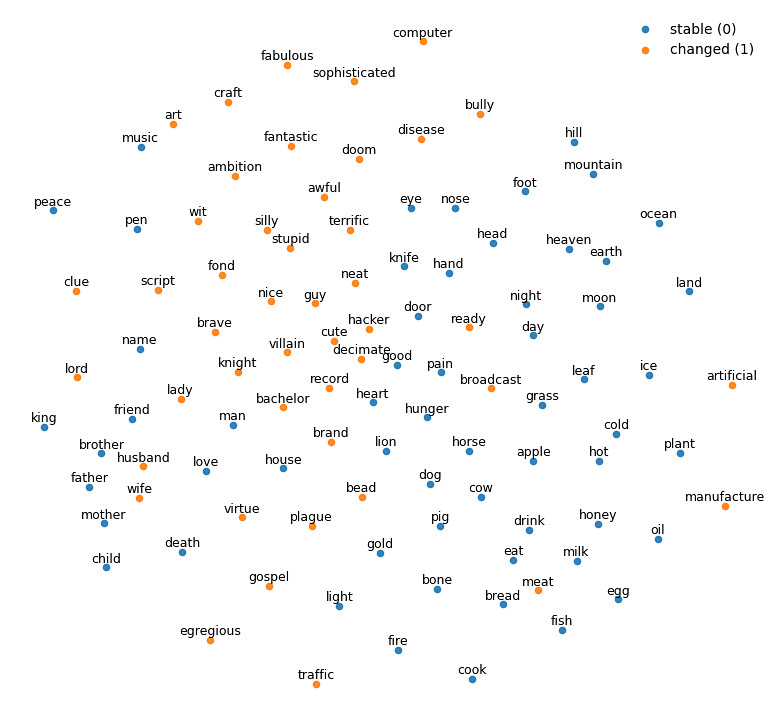

## Introduction

The meanings of words in natural language change over time — some evolve gradually, while others undergo abrupt semantic shifts. Thanks to historical text corpora, it is possible to train vector models that capture these historical differences.

In this task, you will analyze **pretrained embeddings (word2vec)** from two different time periods:

* **1900** — a model trained exclusively on early 20th-century data
* **1990** — a model trained on data close to the modern era

These two models were trained **completely independently**. Your task is to use these representations to build a classifier that determines whether the **meaning of a given word has significantly changed between 1900 and 1990**.

## Task

You will build a **binary classifier** that returns a label for a given word:

* **0 — semantically stable word**
* **1 — word whose meaning has changed**

## Data

* `train.csv` — training set (word + label)
* `valid.csv` — validation set for local testing
* `1900-vocab.pkl` and `1900-w.npy` — vocabulary and embedding matrix from 1900
* `1990-vocab.pkl` and `1990-w.npy` — analogous set for 1990

## Evaluation metric

The solution is evaluated using **Balanced Accuracy**, i.e. the average of classification accuracy for the positive class and the negative class. In other words:

$$ \text{Balanced Accuracy} = \frac{1}{2}(\text{TPR} + \text{TNR}) $$

i.e. the average of sensitivity (TPR) and specificity (TNR).
This metric is robust to class imbalance.

You must output **hard labels (0/1)**.

The notebook includes an `evaluate_algorithm` function that allows you to test your model on `valid.csv`.

You can score between 0 and 100 points for this task. The result is scaled linearly depending on Balanced Accuracy:

* **Balanced Accuracy ≤ 0.7**: 0 points.
* **Balanced Accuracy ≥ 0.87**: 100 points.
* **Values between 0.7 and 0.87**: linearly scaled.

Formula for scoring:
$$
\text{Points} =
\begin{cases}
0 & \text{for } \text{Balanced Accuracy} \leq 0.7 \\
100 \times \frac{\text{Balanced Accuracy} - 0.7}{0.87 - 0.7} & \text{for } 0.7 < \text{Balanced Accuracy} < 0.87 \\
100 & \text{for } \text{Balanced Accuracy} \geq 0.87
\end{cases}
$$

## Constraints

Your notebook will be executed on the Competition Platform:

* **no internet access**
* CPU only (no GPU)
* Execution time limit for the notebook and evaluation on the test set: **5 minutes**
* Allowed libraries: `numpy`, `pandas`, `scikit-learn`, `matplotlib`, `tqdm`

## Submission files

* This notebook completed with your solution:

```python
class SemanticChangeModel:
    def fit(self, train_df):
        ...
    def predict_change(self, words: List[str]) -> List[int in {0,1}]:
        ...
```

## Evaluation

Note that during evaluation, the flag `FINAL_EVALUATION_MODE` will be set to `True`.

You can earn between 0 and 100 points for this task. The number of points will be computed on a (hidden) test set on the Competition Platform using the formula above, rounded to an integer. If your solution does not meet the requirements or fails to run correctly, you will receive 0 points.


## Inicjalizacja środowiska

In [3]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

# Flaga: na platformie oceniającej ustawiana na True
FINAL_EVALUATION_MODE = False

import os, json, pickle, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

from sklearn.metrics import balanced_accuracy_score

np.random.seed(42)
random.seed(42)

DATA_DIR = Path('data')
EMB_DIR  = DATA_DIR / 'embeddings'
EMB_DIR.mkdir(parents=True, exist_ok=True)


## Pobieranie danych (tylko lokalnie)

In [ ]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

# Uwaga: Na platformie oceniającej internet jest wyłączony.
# Ten blok uruchamia się tylko lokalnie (gdy FINAL_EVALUATION_MODE == False).

GDRIVE_FILES = [
    ('1rUGgDZcpwRZ5sRHGxxEh2f7ZJ0DRVDPL', EMB_DIR / '1900-vocab.pkl'),
    ('1cYXPhghcawbMZ6vU2XyJUq7NOpBIKj5E', EMB_DIR / '1900-w.npy'),
    ('1ApLkBn2ylvLMKNlNtvkMVde6RxnLJolI', EMB_DIR / '1990-vocab.pkl'),
    ('1B3NLInA4Ty3lUaHNQgxtDTKJNtG0t0T1', EMB_DIR / '1990-w.npy'),
    ('1hrOfZOq3BV1K0tWe6HSZG-OiZkGlCiYT', DATA_DIR / 'train.csv'),
    ('1vndyCuDCBP6zLvNkF_YsKHgTQgulTjt_', DATA_DIR / 'valid.csv'),
]

def download_data():
    try:
        import gdown
    except Exception as e:
        raise RuntimeError('Please install gdown locally: `pip install gdown`') from e

    DATA_DIR.mkdir(parents=True, exist_ok=True)
    EMB_DIR.mkdir(parents=True, exist_ok=True)

    for fid, out_path in GDRIVE_FILES:
        if out_path.exists():
            print(f'Skipping download, file already exists: {out_path.name}')
            continue
        url = f'https://drive.google.com/uc?id={fid}'
        out_path.parent.mkdir(parents=True, exist_ok=True)
        print(f'Downloading -> {out_path.name}')
        gdown.download(url, str(out_path), quiet=False)

if not FINAL_EVALUATION_MODE:
    download_data()
    print('Download complete.')
else:
    print('FINAL_EVALUATION_MODE=True — pomijam pobieranie (na platformie dane są dostarczone).')

## Ładowanie embeddingów i zbiorów danych

In [5]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################

def load_histwords_decade(decade: int, emb_dir: Path):
    vocab_path = emb_dir / f'{decade}-vocab.pkl'
    w_path     = emb_dir / f'{decade}-w.npy'
    with open(vocab_path, 'rb') as f:
        vocab = pickle.load(f)
    W = np.load(w_path)
    # L2 normalize
    W = W / (np.linalg.norm(W, axis=1, keepdims=True) + 1e-12)
    w2i = {w:i for i,w in enumerate(vocab)}
    return vocab, W, w2i

# Load embeddings
vocab_1900, W1900, w2i_1900 = load_histwords_decade(1900, EMB_DIR)
vocab_1990, W1990, w2i_1990 = load_histwords_decade(1990, EMB_DIR)

print(f'1900: V={len(vocab_1900):,}, dim={W1900.shape[1]}')
print(f'1990: V={len(vocab_1990):,}, dim={W1990.shape[1]}')

# Load train/valid
train_path = DATA_DIR / 'train.csv'
valid_path = DATA_DIR / 'valid.csv'
# test_path = DATA_DIR / 'test.csv'
assert train_path.exists() and valid_path.exists(), 'train.csv / valid.csv not found in data/'

train_df = pd.read_csv(train_path)
valid_df = pd.read_csv(valid_path)
# test_df = pd.read_csv(test_path)

# Expect columns: word,label
for c in ['word', 'label']:
    assert c in train_df.columns and c in valid_df.columns, 'Expected columns: word,label'

train_df['word'] = train_df['word'].astype(str).str.lower().str.strip()
valid_df['word'] = valid_df['word'].astype(str).str.lower().str.strip()
# test_df['word'] = test_df['word'].astype(str).str.lower().str.strip()
train_df['label'] = train_df['label'].astype(int)
valid_df['label'] = valid_df['label'].astype(int)
# test_df['label'] = test_df['label'].astype(int)

print(train_df.head(5))
print()
print(valid_df.head(5))

print(f'train: {len(train_df)}, valid: {len(valid_df)}')

1900: V=100,000, dim=300
1990: V=100,000, dim=300
        word  label
0     lichen      0
1    imaging      1
2      devil      0
3    prayers      0
4  frankfort      1

        word  label
0  coastline      0
1       yoke      0
2     report      1
3   language      0
4       barn      0
train: 2495, valid: 832


In [6]:
def print_neighbors(word, V, vocab, w2i, label):
    vec = V[w2i[word]]
    sims = V @ vec
    sims[w2i[word]] = -np.inf
    top = np.argsort(-sims)[:10]
    print(f"\nTop 10 neighbors in {label}:")
    for i in top:
        print(f"  {vocab[i]}  ({sims[i]:.4f})")

print_neighbors("frankfort", W1900, vocab_1900, w2i_1900, "1900")
print_neighbors("frankfort", W1990, vocab_1990, w2i_1990, "1990")


Top 10 neighbors in 1900:
  mannheim  (0.4496)
  munich  (0.4368)
  budapest  (0.4340)
  1545  (0.4324)
  hamburg  (0.4314)
  buda  (0.4223)
  cologne  (0.4222)
  leipzig  (0.4208)
  zurich  (0.4199)
  augsburg  (0.4121)

Top 10 neighbors in 1990:
  piraeus  (0.4138)
  1097  (0.3696)
  fronting  (0.3682)
  ky  (0.3681)
  699  (0.3656)
  1320  (0.3643)
  1206  (0.3631)
  barnwell  (0.3561)
  4900  (0.3527)
  1550  (0.3507)


# Model Solution

The following solution walks through the full machine learning pipeline, from data exploration to evaluation on the validation set.
A combination of **HistGradientBoosting** and **Logistic Regression** models is used as the classifier.
To achieve strong performance, it is necessary to design appropriate features that allow predicting whether a word has changed its meaning.

The solution is divided into the following steps:

* [1. Data exploration](#1.-Data-exploration)

  * [1.1 Basic information](#1.1-Basic-information)
  * [1.2 Data validation](#1.2-Data-validation)
  * [1.3 Data transformation](#1.3-Data-transformation)

    * [1.3.1 Diachronic embeddings](#1.3.1-Diachronic-embeddings)
    * [1.3.2 Selecting stable anchor points](#1.3.2-Selecting-stable-anchor-points)
    * [1.3.3 Aligning spaces using Procrustes method](#1.3.3-Aligning-spaces-using-Procrustes-method)
* [2. Feature engineering](#2.-Feature-engineering)

  * [2.1 Direct distances (First Order Similarity)](#2.1-Direct-distances)
  * [2.2 Second-order similarity profiles](#2.2-Second-order-similarity-profiles)
  * [2.3 Diverse anchor sets](#2.3-Diverse-anchor-sets)
  * [2.4 Rank shift analysis (Rank Distance)](#2.4-Rank-shift-analysis)
* [3. Model architecture (Stacking Ensemble)](#3.-Model-architecture)

  * [3.1 Base models: HistGradientBoosting and Logistic Regression](#3.1-Base-models)
  * [3.2 Meta-classifier and probability aggregation](#3.2-Meta-classifier)
* [4. SemanticChangeModel class](#4.-SemanticChangeModel-class)
* [5. Training and evaluation cycle](#5.-Training-and-evaluation-cycle)

  * [5.1 Training with Out-of-Fold (OOF)](#5.1-Training-with-Out-of-Fold)
  * [5.2 Decision threshold optimization](#5.2-Decision-threshold-optimization)
  * [5.3 Validation results (Balanced Accuracy)](#5.3-Validation-results)


## 1. Data exploration

Before implementing the classifier, we start with data exploration. This is a key part of solving any machine learning problem. Exploratory Data Analysis (EDA) helps us understand the training data, validate it, and correct any potential missing values or noise it may contain.


### 1.1 Basic information

We begin by checking the general properties of the available datasets. This includes inspecting characteristics such as: number of observations, number of features, and missing values.

In this task, we have access to datasets from two different time periods (1900 and 1990). Specifically:

* `train.csv` — training set (word + label)
* `valid.csv` — validation set for local testing
* `1900-vocab.pkl` and `1900-w.npy` — vocabulary and embedding matrix from 1900
* `1990-vocab.pkl` and `1990-w.npy` — analogous set for 1990


In [7]:
# sprawdzenie ilości obserwacji w zbiorze treningowym i walidacyjnym
print(f'Liczba obserwacji w zbiorze treningowym: {len(train_df)}')
print(f'Liczba obserwacji w zbiorze walidacyjnym: {len(valid_df)}')

# sprawdzenie rozmiaru słownika dla obu lat
print(f'Rozmiar słownika 1900: {len(vocab_1900)}')
print(f'Rozmiar słownika 1990: {len(vocab_1990)}')

# sprawdzenie długości wektorów osadzeń
print(f'Długość wektorów osadzeń 1900: {W1900.shape[1]}')
print(f'Długość wektorów osadzeń 1990: {W1990.shape[1]}')

Liczba obserwacji w zbiorze treningowym: 2495
Liczba obserwacji w zbiorze walidacyjnym: 832
Rozmiar słownika 1900: 100000
Rozmiar słownika 1990: 100000
Długość wektorów osadzeń 1900: 300
Długość wektorów osadzeń 1990: 300


In [8]:
# sprawdzenie braku danych w zbiorach treningowym i walidacyjnym
print(f'Liczba brakujących wartości w zbiorze treningowym:\n{train_df.isnull().sum()}')
print(f'Liczba brakujących wartości w zbiorze walidacyjnym:\n{valid_df.isnull().sum()}')

Liczba brakujących wartości w zbiorze treningowym:
word     0
label    0
dtype: int64
Liczba brakujących wartości w zbiorze walidacyjnym:
word     0
label    0
dtype: int64


In [9]:
# Przykładowe dane
print(train_df.head(5))

        word  label
0     lichen      0
1    imaging      1
2      devil      0
3    prayers      0
4  frankfort      1


### 1.2 Data validation

After the initial exploration of the basic properties of the data, we perform validation of the training and validation datasets to ensure they are suitable for further analysis and modeling. The validation includes:

* Comparing the distribution of the target variable across datasets
* Checking whether words from both datasets are present in both vocabularies (1900 and 1990)


In [10]:
# porównanie rozkładów zmiennej celu w zbiorze treningowym i walidacyjnym
print(f'Rozkład zmiennej celu w zbiorze treningowym:\n{train_df["label"].value_counts(normalize=True)}')
print(f'Rozkład zmiennej celu w zbiorze walidacyjnym:\n{valid_df["label"].value_counts(normalize=True)}')

Rozkład zmiennej celu w zbiorze treningowym:
label
0    0.569138
1    0.430862
Name: proportion, dtype: float64
Rozkład zmiennej celu w zbiorze walidacyjnym:
label
0    0.569712
1    0.430288
Name: proportion, dtype: float64


The distributions of the target variable are very similar between the training and validation sets, which is clearly desirable.

The ratio of the positive class to the negative class is slightly imbalanced and is approximately 57% to 43%. This should be taken into account when building a binary classifier.


In [11]:
# Sprawdzenie nieobecności słów ze zbioru treningowego i walidacyjnego w słownikach dla obu lat
train_words_missing_1900 = (~train_df['word'].isin(w2i_1900)).sum()
train_words_missing_1990 = (~train_df['word'].isin(w2i_1990)).sum()
valid_words_missing_1900 = (~valid_df['word'].isin(w2i_1900)).sum()
valid_words_missing_1990 = (~valid_df['word'].isin(w2i_1990)).sum()

print(f'Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1900: {train_words_missing_1900}')
print(f'Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1990: {train_words_missing_1990}')
print(f'Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1900: {valid_words_missing_1900}')
print(f'Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1990: {valid_words_missing_1990}')


# Sprawdzenie czy maksymalny indeks w słowniku odpowiada rozmiarowi macierzy embeddingów
max_index_1900 = max(w2i_1900.values()) + 1 # dodajemy 1, bo indeksy zaczynają się od 0
max_index_1990 = max(w2i_1990.values()) + 1
print(f'Max indeks w słowniku 1900 (licząc od 1): {max_index_1900}, rozmiar macierzy embeddingów: {W1900.shape[0]}')
print(f'Max indeks w słowniku 1990 (licząc od 1): {max_index_1990}, rozmiar macierzy embeddingów: {W1990.shape[0]}')

Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1900: 0
Liczba słów ze zbioru treningowego BRAKUJĄCYCH w słowniku 1990: 0
Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1900: 0
Liczba słów ze zbioru walidacyjnego BRAKUJĄCYCH w słowniku 1990: 0
Max indeks w słowniku 1900 (licząc od 1): 100000, rozmiar macierzy embeddingów: 100000
Max indeks w słowniku 1990 (licząc od 1): 100000, rozmiar macierzy embeddingów: 100000


All words from the training and validation sets are present in the vocabularies, and the sizes of the vocabularies match the embedding matrices. This guarantees that every word in the dataset has a corresponding vector representation in both the 1900 and 1990 word spaces.

Let us also visually inspect how words are distributed in the 1900 and 1990 embedding spaces. For this purpose, we will use [t-SNE (t-Distributed Stochastic Neighbor Embedding)](https://en.wikipedia.org/wiki/T-distributed_stochastic_neighbor_embedding). This is a non-linear dimensionality reduction technique that visualizes high-dimensional data in a 2D or 3D space by grouping similar data points into clusters, making it easier to explore, analyze, and understand the structure of the dataset.


c:\Users\48601\anaconda3\envs\zmiany_semantyczne\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


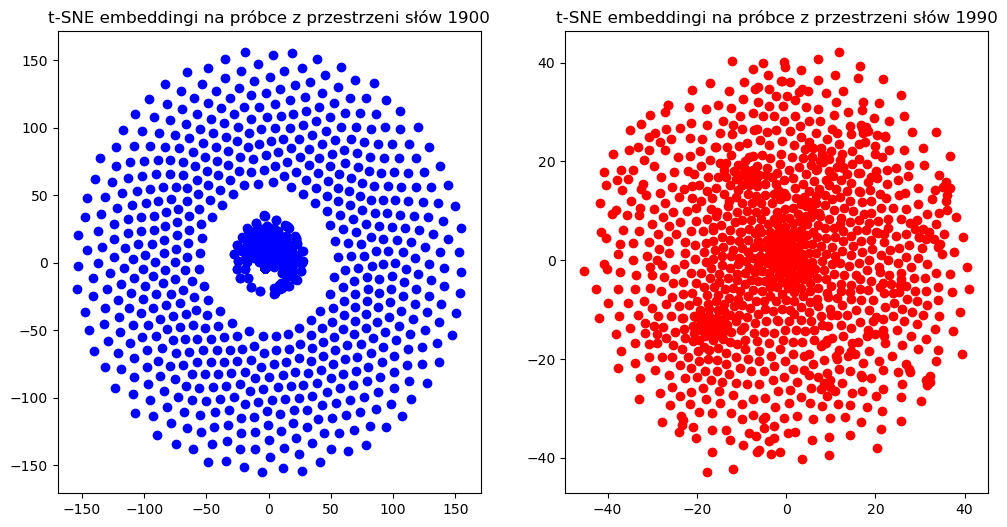

In [12]:
# Wizualizacja wektorów osadzeń dla losowo wybranych słów z obu lat za pomocą t-SNE
from sklearn.manifold import TSNE

rng = np.random.default_rng(42)
sample_words = rng.choice(list(train_df['word']), size=1000, replace=False).tolist() # wybieramy 1000 losowych słów z zbioru treningowego
embeddings_1900 = np.array([W1900[w2i_1900[word]] for word in sample_words if word in w2i_1900])
embeddings_1990 = np.array([W1990[w2i_1990[word]] for word in sample_words if word in w2i_1990])
tsne_1900 = TSNE(n_components=2, random_state=42).fit_transform(embeddings_1900)
tsne_1990 = TSNE(n_components=2, random_state=42).fit_transform(embeddings_1990)
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.scatter(tsne_1900[:, 0], tsne_1900[:, 1], color='blue')
plt.title('t-SNE embeddingi na próbce z przestrzeni słów 1900')
plt.subplot(1, 2, 2)
plt.scatter(tsne_1990[:, 0], tsne_1990[:, 1], color='red')
plt.title('t-SNE embeddingi na próbce z przestrzeni słów 1990')
plt.show()

It is worth noting the differences in the local structure of both spaces. In 1900, the distribution of points appears more uniform and dispersed, which may suggest lower semantic polarization in the sampled vocabulary. In contrast, the 1990 plot shows a tendency to form more distinct and denser clusters. This may indicate stronger categorization of concepts or the emergence of specific contextual niches in the more modern corpus.

The axis scales differ between the two plots, which is typical for the t-SNE algorithm and results from its stochastic nature and lack of preservation of global distances. The axis values themselves do not carry meaningful information about word similarity, so they should not be directly compared.

It is important to remember that we are comparing **two independently trained** vector spaces. Without aligning the embedding spaces, any comparison between them is only qualitative. The necessary transformations of the data are discussed in the next section.


### 1.3 Data transformation

The transformation process is a critical stage in preparing data for the task of detecting semantic change. Since we are comparing two separate word2vec vector models (trained independently on corpora from different eras), we cannot directly compare their coordinates without first bringing them into a shared reference space.

The issue is that the vectors (word coordinates) from 1900 and 1990 exist in two completely different “mathematical languages.” Even if a word has not changed its meaning at all, its coordinates in both representations will still be different. We must align them before performing any comparisons.


#### 1.3.1 Diachronic embeddings

Diachronic embeddings are vector representations of words that capture their meaning within specific time periods. In this task, we operate on two spaces: $W_{1900}$ and $W_{1990}$.

The key challenge is the lack of invariance across different embedding spaces. This means that even if a word’s meaning had not changed at all, its vectors in two separately trained models may be rotated or shifted relative to each other. Therefore, the first step is to understand that differences in raw coordinates are not a measure of semantic change, but rather a consequence of the training process of the models.


#### 1.3.2 Selecting stable anchor points

To align the two spaces, we need to identify fixed points (**anchors**) — words that we assume have not changed their semantic position (i.e., are semantically stable).

The anchor selection process is as follows:

* We select only stable words that appear in the vocabularies of both epochs.
* For efficiency reasons and to avoid overfitting to noise, we limit the final number of anchors to $N=400$.
* If more stable words are available, we randomly sample a subset of them, which provides the model with a stable “reference base” distributed across different regions of the semantic space.

These anchors act as “pins” that allow us to align one map onto another. If the pins are correctly aligned, then any remaining differences in word positions can be interpreted as actual semantic change rather than arbitrary rotation of the embedding space.


In [13]:
# Wybieramy słowa stabilne (label 0)
stable_words = train_df[train_df['label'] == 0]['word'].tolist()
common_anchors = [i for i in range(len(stable_words)) if stable_words[i] in w2i_1900 and stable_words[i] in w2i_1990]
anchor_idx_1900 = [w2i_1900[stable_words[i]] for i in common_anchors]
anchor_idx_1990 = [w2i_1990[stable_words[i]] for i in common_anchors]

#### 1.3.3 Aligning spaces using the Procrustes method

The most important part of the transformation is the Orthogonal Procrustes Problem. This method finds an optimal rotation matrix $R$ that minimizes the sum of squared distances between anchor vectors in both spaces. We use this approach following its application in the literature ([Hamilton et al., 2016](https://arxiv.org/pdf/1605.09096)).

Mathematically, we seek a matrix $R$ that satisfies:
$$R = \arg\min_{\Omega} | \Omega A - B |_F \quad \text{subject to orthogonality} \quad \Omega^T\Omega = I$$
where $A$ and $B$ are matrices of anchor vectors from 1990 and 1900 respectively, and $| \cdot |_F$ denotes the Frobenius norm.

The implementation relies on [singular value decomposition (SVD)](https://pl.wikipedia.org/wiki/Rozk%C5%82ad_wed%C5%82ug_warto%C5%9Bci_osobliwych). The authors of the above paper justify this method as it provides the best possible linear transformation based on earlier work ([Schoenemann, 1966](https://web.stanford.edu/class/cs273/refs/procrustes.pdf)). The transformation is computed as follows:

1. Compute the matrix product $M = B^T A$ after L2-normalizing both $A$ and $B$.
2. Perform SVD: $SVD(M) = U \Sigma V^T$.
3. The optimal rotation matrix is $R = U V^T$.

**Intuition:** the Procrustes method finds a rotation that minimizes alignment error between two sets of anchor points:

1. **Matrix product:** We first measure how anchor vectors from one era are positioned relative to their counterparts in the other.
2. **SVD decomposition:** Instead of manually optimizing transformation parameters, we use SVD, which breaks these relationships into components and provides an optimal rotation that minimizes mismatch.
3. **Effect:** After applying the rotation matrix, both spaces are placed in a shared coordinate system.

After computing $R$, the entire matrix $W_{1990}$ is transformed ($W_{1990} \times R$), enabling direct cosine similarity computation between vectors from both epochs. Finally, both matrices are L2-normalized, ensuring all word vectors lie on the unit hypersphere. In this space, only angular distance matters (the smaller the angle, the more similar the words).

**Why does this work?** The effectiveness of this method relies on the assumption that word embedding spaces are approximately isomorphic — meaning their internal relational structure remains stable over time, while only the coordinate system changes orientation. Using an orthogonal transformation (instead of a full affine transformation) is optimal because it preserves dot products, which encode semantic relationships in word2vec models.

An affine transformation (including translation, i.e., shifting every point by a constant vector) could distort the geometry of the space, since shifting vectors changes angles between them in a nonlinear way. Additionally, translation would move the natural origin of the space ($[0, \dots, 0]^T$), removing semantic interpretability — in SGNS (Skip-gram with negative sampling), embeddings are naturally centered around zero.

The key requirement is therefore orthogonality ($\Omega^T\Omega = I$), which preserves cosine distances and protects semantic relationships from artificial deformation.


In [14]:
def normalize(X):
    """Funkcja pomocnicza do normalizacji L2 wektorów osadzeń."""
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    return X / norms

# 1.3.3 Wyrównanie przestrzeni metodą Prokrustesa
def procrustes_align(W_src: np.ndarray, W_tgt: np.ndarray, words_list: list[str], w2i_src: dict[str, int], w2i_tgt: dict[str, int]) -> np.ndarray:
    """Wyrównanie przestrzeni źródłowej W_src do przestrzeni docelowej W_tgt za pomocą metody Prokrustesa."""
    # 1. Wybranie tylko wspólnych wektorów kotwic i normalizacja
    anchors_src = normalize(np.vstack([W_src[w2i_src[w]] for w in words_list]))
    anchors_tgt = normalize(np.vstack([W_tgt[w2i_tgt[w]] for w in words_list]))
    
    # 2. Obliczenie macierzy korelacji (Cross-correlation matrix): M = B^T @ A (według wzoru z opisu)
    M = anchors_tgt.T @ anchors_src
    
    # 3. Rozkład SVD
    U, _, Vt = np.linalg.svd(M)
    
    # 4. Wyznaczenie optymalnej rotacji R = U @ Vt
    R = U @ Vt
    
    # 5. Przekształcenie całej przestrzeni źródłowej z normalizacją L2
    W_src_aligned = normalize(W_src @ R.T)
    
    return W_src_aligned


# Wykonujemy wyrównanie (upraszczając do tych samych indeksów co w 1.3.2 dla czytelności przykładu)
W1990_aligned = procrustes_align(W1990, W1900, stable_words, w2i_1990, w2i_1900)
# Normalizacja macierzy źródłowych aby porównanie dystansów było bardziej miarodajne
W_1900_norm = normalize(W1900)
W_1990_norm = normalize(W1990)

# Wizualizacja efektu: Porównanie pozycji przykładowego pierwszego stabilnego słowa w dwóch przestrzeniach
sample_word = train_df[train_df['label'] == 0]['word'].iloc[0]
idx_1900 = w2i_1900[sample_word]
idx_1990 = w2i_1990[sample_word]

print(f"Słowo: {sample_word}, dystans pomiędzy reprezentacjami w przestrzeniach 1900 i 1990:")
print(f"Dystans przed wyrównaniem: {np.linalg.norm(W_1900_norm[idx_1900] - W_1990_norm[idx_1990]):.4f}")
print(f"Dystans po wyrównaniu: {np.linalg.norm(W_1900_norm[idx_1900] - W1990_aligned[idx_1990]):.4f}")

Słowo: lichen, dystans pomiędzy reprezentacjami w przestrzeniach 1900 i 1990:
Dystans przed wyrównaniem: 1.1939
Dystans po wyrównaniu: 0.9065


## 2. Feature engineering

After aligning the embedding spaces, each word is represented by two vectors in the same coordinate system. The goal of this stage is to transform these vector pairs into a set of features that capture different types of semantic shifts.

Feature engineering is a crucial step in the entire solution, as the final performance depends heavily on the quality of the constructed features. In the following subsections, we will discuss the different groups of features that can be used in this task.


### 2.1 Direct distances

The most intuitive measure of semantic change is the geometric distance between a word’s representation in 1900 and its corresponding representation in 1990. We use two common metrics:

* **Cosine Similarity**: A angular measure between the word vector from 1900 and the aligned vector from 1990. It captures changes in vector direction, which reflect changes in usage context. It is computed as follows:
  $$\text{cosine\_sim}(\mathbf{u}, \mathbf{v}) = \frac{\mathbf{u} \cdot \mathbf{v}}{|\mathbf{u}| |\mathbf{v}|} = \frac{\sum_{i=1}^{n} u_i v_i}{\sqrt{\sum_{i=1}^{n} u_i^2} \sqrt{\sum_{i=1}^{n} v_i^2}}$$

In this solution, we use **cosine distance**, derived directly from cosine similarity:
$$\text{cosine\_distance}(\mathbf{u}, \mathbf{v}) = 1 - \text{cosine\_sim}(\mathbf{u}, \mathbf{v})$$

* **L2 Distance (Euclidean Distance)**: The geometric distance between points in space. For normalized vectors, this feature is correlated with cosine similarity, but can still capture subtle differences in spatial positioning:
  $$\text{euclidean\_dist}(\mathbf{u}, \mathbf{v}) = |\mathbf{u} - \mathbf{v}|*2 = \sqrt{\sum*{i=1}^{n} (u_i - v_i)^2}$$

First-order similarity features measure global displacement.


In [15]:
# obliczanie dystansu cosinusowego i euklidesowego dla tych samych słów w obu przestrzeniach embeddingów na przykładzie losowo wybranego słowa
word = random.choice(train_df['word'].tolist())
v1, v2 = W1900[w2i_1900[word]], W1990[w2i_1990[word]]
cosine_distance = 1 - np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
euclidean_distance = np.linalg.norm(v1 - v2)
print(f'Dystans cosinusowy dla słowa "{word}": {cosine_distance:.4f}')
print(f'Dystans euklidesowy dla słowa "{word}": {euclidean_distance:.4f}')

Dystans cosinusowy dla słowa "hats": 0.5579
Dystans euklidesowy dla słowa "hats": 1.0563


### 2.2 Second-order similarity profiles

This approach assumes that the meaning of a word is defined not by its position in isolation, but by its relationship to stable reference points in the language. Even if the global alignment of the spaces using the Procrustes method is not perfect, SOS (Second-Order Similarity) profiles enable precise local analysis.

These features are significantly more robust to noise because they do not rely on raw coordinates, but on relational structure. A word may exhibit a small geometric shift, but if its similarity ranking relative to stable concepts has been reconfigured (e.g., the word “cell” becoming closer to “phone” and further from “biology”), the Second Order Similarity profile will capture this contextual change, which might be underestimated by global cosine distance.

We compute these features by comparing similarity profiles:

* **Second-Order Cosine Distance**: The model builds a similarity profile of a word relative to stable anchors in 1900 and an analogous profile in 1990. It then computes the cosine distance between these two profiles.

* **Second-Order L2 Distance**: The Euclidean distance between the two profile vectors.


In [16]:
# Budowa profilu relacji względem stabilnych słów - na przykładzie pierwszych 5 stabilnych słów-sond (probe words)

# Wybór 5 stabilnych słów jako sondy (kotwice)
stable_probes = train_df[train_df['label'] == 0]['word'].head(5).tolist()
probe_idx1 = [w2i_1900[w] for w in stable_probes]
probe_idx2 = [w2i_1990[w] for w in stable_probes]

# Pobranie wektorów sond
probes_v1 = W1900[probe_idx1]
probes_v2 = W1990_aligned[probe_idx2]

# Wybór badanego słowa (np. pierwszego z brzegu)
test_word = train_df['word'].iloc[0]
v1 = W1900[w2i_1900[test_word]]
v2 = W1990_aligned[w2i_1990[test_word]]

# Profil SOS: podobieństwo badanego słowa do każdej z 5 sond
sos_profile1 = v1.dot(probes_v1.T)
sos_profile2 = v2.dot(probes_v2.T)

print("profil SOS dla słowa '{}':".format(test_word))
sos_df = pd.DataFrame({
    'probe_word': stable_probes,
    'podobienstwo_profilu_1900': sos_profile1,
    'podobienstwo_profilu_1990': sos_profile2
})
print(sos_df)

profil SOS dla słowa 'lichen':
  probe_word  podobienstwo_profilu_1900  podobienstwo_profilu_1990
0     lichen                   1.000000                   1.000000
1      devil                  -0.065169                   0.023794
2    prayers                  -0.028219                  -0.000271
3   eyebrows                   0.130505                   0.123314
4  streaming                   0.230388                   0.092982


### 2.3 Diverse anchor sets

To obtain a multi-perspective view of semantic change, we do not rely on a single reference point, but instead analyze word behavior relative to different layers of vocabulary. Several anchor sets are defined in the model:

* Frequency-based sets (Top 100, 500, 1000): Represent the most stable core of the language.
* Random sets: Allow capturing correlations with less obvious, rarer semantic regions.

Different words change meaning in different ways — some drift away from everyday contexts, others from technical ones. Computing statistics (mean, median, standard deviation) across multiple anchor groups allows the model to average out noise and stabilize predictions.

For each anchor set (e.g., Top 100 most frequent words, Top 500, random set), we compute:

* **Delta Sim (Similarity difference)**: The value
  $$|\text{Sim}(w, anchor)*{1990} - \text{Sim}(w, anchor)*{1900}|$$
  where $\text{Sim}$ is computed via dot product: $\text{Sim}(X, Y) = X \cdot Y^T$.

* Aggregated statistics for each set:

  * **Mean**: Average change in similarity to all anchors in the set.
  * **Std**: Indicates whether a word changed uniformly across all anchors or only relative to specific ones.
  * **Median** and **Max**: Capture extreme semantic shifts that could be smoothed out by the mean.


In [17]:
# Przykład - pobieramy pierwsze 50 słów z modelu jako demonstracyjny zestaw kotwic
anchors_idx = np.arange(50)
a1 = W1900[anchors_idx]
a2 = W1990_aligned[anchors_idx]

# Podobieństwo badanego słowa do całego zestawu kotwic
sims1 = v1.dot(a1.T)
sims2 = v2.dot(a2.T)

# Różnica bezwzględna (delta)
adiff = np.abs(sims2 - sims1)

# Agregacja do cech (np. średnia zmiana względem kotwic)
anchor_feature_mean = adiff.mean()
print(f"Średnia zmiana podobieństwa względem kotwic: {anchor_feature_mean:.4f}")

Średnia zmiana podobieństwa względem kotwic: 0.0703


### 2.4 Rank shift analysis

This is the most advanced feature of the model, which moves away from raw similarity values toward the structure of neighborhood relations. For each anchor set, the model sorts anchors by their similarity to the target word, creating a ranking. We then measure how much each anchor’s position in this ranking has shifted between 1900 and 1990.

Cosine similarity values may change due to differences in corpus size or training conditions. However, the hierarchy of concepts is typically more stable. **Intuitively**, if the word “castle” had “king” among its top 10 nearest neighbors in 1900, but in 1990 “king” drops to rank 500, this provides strong, non-parametric evidence of semantic change (so-called rank displacement).

The features used are:

* **Rank Displacement**: For each anchor in a given set, the model checks its position in the nearest-neighbor ranking of the word in 1900 and in 1990 (e.g., in 1900 the anchor is the 2nd closest neighbor, while in 1990 it drops to position 40).

* **Ranking statistics**:

  * **Mean Rank Displacement**: Average reshuffling across the entire neighbor list.
  * **Std Rank Displacement**: Variability of rank shifts.
  * **Median & Max Rank Displacement**: Maximum positional jump in the ranking, which is a strong signal of semantic change (e.g., sudden emergence of a new dominant meaning).


In [18]:
# Sortowanie indeksów kotwic według podobieństwa (od największego) wykorzystując przykład z 2.3
# argsort zwraca pozycje, które posortowałyby tablicę
rank1 = np.argsort(-sims1) # pozycje kotwic w 1900
rank2 = np.argsort(-sims2) # pozycje kotwic w 1990

# Obliczamy, na której pozycji w rankingu znalazła się każda kotwica
pos1 = np.argsort(rank1)
pos2 = np.argsort(rank2)

# Odległość rankingowa dla każdej kotwicy
rank_distances = np.abs(pos1 - pos2)

print(f"Średni Rank Distance (przesunięcie w rankingu): {rank_distances.mean():.2f}")

Średni Rank Distance (przesunięcie w rankingu): 14.56


## 3. Model architecture

The final classification decision is not made by a single algorithm, but by an ensemble of models organized in a stacking architecture. This approach is based on the assumption that different families of algorithms learn different aspects of the data: tree-based models are excellent at capturing thresholds and non-linearities, while linear models are better at capturing general trends.


### 3.1 Base models

In the first layer of our ensemble, two independent base classifiers operate on the feature vectors extracted in the previous step:

* **HistGradientBoostingClassifier (HGB)**: A modern implementation of gradient-boosted decision trees. Its main role is to identify complex relationships between features. HGB can capture patterns such as: a rank shift above a certain threshold, combined with a low cosine distance, being a stronger signal of semantic change than either feature alone.

* **Logistic Regression (LR)**: Acts as a stabilizing component of the ensemble. As a linear model, it learns an optimal separating hyperplane between stable and changed words. It is less prone to overfitting in ambiguous cases, which improves generalization to words not seen during training.


### 3.2 Meta-classifier and probability aggregation

The second layer of the architecture is the so-called meta-classifier, which acts as an arbiter making the final decision based on the “opinions” produced by the base models.

* Aggregation of predictions: The base models do not pass hard labels (0 or 1) to the meta-classifier, but rather raw probabilities (`predict_proba`). This preserves information about each model’s confidence or uncertainty regarding a given observation.

* Role of the meta-classifier (Logistic Regression): The meta-classifier learns to optimally weight the outputs of the base models, identifying which one is statistically less error-prone under specific prediction combinations. This enables effective calibration of model confidence and compensation for their individual biases, without requiring re-analysis of the raw features.

* Ensemble advantage: Such an ensemble is significantly more robust to individual model errors. It combines the strong predictive power of gradient-based models with the stability and simplicity of statistical models, which directly translates into higher Balanced Accuracy.


In [19]:
# Załóżmy, że X to macierz cech wygenerowana dla słów w train_df
# Tutaj symulujemy ją na podstawie rozmiaru train_df i 12 cech
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


X = np.random.rand(len(train_df), 12) 
y = train_df['label'].values

# Modele bazowe trenowane na realnych etykietach
hgb = HistGradientBoostingClassifier().fit(X, y)
lr = LogisticRegression(max_iter=1000).fit(X, y)

# Meta-cechy: prawdopodobieństwa z modeli bazowych
meta_X = np.column_stack([
    hgb.predict_proba(X)[:, 1],
    lr.predict_proba(X)[:, 1]
])

# Meta-klasyfikator uczący się jak łączyć te wyniki
meta_clf = LogisticRegression().fit(meta_X, y)

print(f"Symulowane prawdopodobieństwo zmiany (Meta) dla pierwszego słowa ze zbioru treningowego ({train_df['word'].iloc[0]}): {meta_clf.predict_proba(meta_X[:1])[:, 1][0]:.4f}")

Symulowane prawdopodobieństwo zmiany (Meta) dla pierwszego słowa ze zbioru treningowego (lichen): 0.0333


### 4. `SemanticChangeModel` class

The `SemanticChangeModel` class is the core of the entire solution. It is designed as a unified interface integrating all previously described stages: from geometric alignment of embedding spaces, through multi-level feature extraction, to inference using an ensemble of models.

By encapsulating all logic within a single class, the semantic change detection process becomes reproducible and robust against implementation errors, while also remaining compatible with the scikit-learn paradigm (use of `fit` and `predict` methods).

#### Class structure and components

The class is divided into modules responsible for model state, transformations, and classification:

* **State and parameters:**

  * *W1900* / *W1990_aligned*: Embedding matrices representing both language states. After calling `fit`, the 1990 matrix is stored in aligned form.

  * **Anchor sets**: A collection of index sets (frequency-based and random) used as reference points for second-order similarity features.

  * **Probe indices**: A set of words considered absolutely stable, used to build SOS similarity profiles.

* **Helper methods:**

  * `_normalize_rows()`: Ensures that all vector operations are performed on the unit sphere, which is essential for correct cosine distance computation.

  * `_align_spaces()`: Performs Procrustes alignment — selecting stable words, computing the SVD decomposition, projecting the $W_{1990}$ matrix, and normalizing both spaces.

  * `_extract_features()`: The most complex method of the class. It aggregates information from direct distances, anchor-based statistics, and neighborhood rank differences.

* **Ensemble decision system:**

  * `self.clf_hgb` / `self.clf_lr`: Two base models (tree-based and linear) that independently analyze the extracted features.

  * `self.clf_meta`: A higher-level model that learns optimal weighting of base model predictions.

  * `self.scaler`: A standardization step ensuring that features with different scales (e.g., small cosine distances vs. large rank shifts) contribute equally during training.

* **Training and inference:**

  * `fit()`: Executes the full training pipeline: Procrustes alignment using stable words, feature generation for the training set, and ensemble training with Out-of-Fold strategy.

  * `predict_change()`: Final inference method that generates features for input words, passes them through the ensemble, and returns binary predictions (0 or 1) based on an optimized decision threshold.

---

## 5. Training and evaluation cycle

The training process of the `SemanticChangeModel` is designed to fully exploit the available training data while avoiding overfitting. A key aspect is the synchronization of feature engineering with multi-stage ensemble learning.

### 5.1 Training with Out-of-Fold

To allow the meta-classifier (Logistic Regression) to learn optimal weighting of base models, it must not be trained on predictions derived from data the base models have already seen. Therefore, we use an **Out-of-Fold (OOF)** strategy with 5-fold stratified cross-validation (`StratifiedKFold`):

1. **Data split:** The training set is divided into 5 subsets.
2. **Rotational training:** In each iteration, base models (HGB and LR) are trained on 4 folds and generate probabilities for the held-out fold.
3. **Meta-feature construction:** After all 5 iterations, we obtain clean predictions for the entire training set. These probabilities become input features for the meta-classifier.

### 5.2 Decision threshold optimization

Standard binary classifiers typically use a decision threshold of $0.5$. However, in semantic shift detection, where classes are slightly imbalanced ($57%$ stable words vs. $43%$ changed), this threshold is optimized to maximize **Balanced Accuracy**.

* **Threshold $0.57$**: Empirically selected as the point of best performance across both classes. Increasing the threshold above $0.5$ makes the classifier more conservative in predicting the positive class.
* **Rationale**: This calibration helps filter out noise caused by minor vector fluctuations that do not represent true semantic change, but rather artifacts of word2vec training. The model labels a word as changed only when the ensemble signal is strong enough to override the natural tendency toward semantic stability.

### 5.3 Validation results

Final evaluation is performed using **Balanced Accuracy**, which is crucial due to class imbalance (typically far more stable words than changing ones).

* **Ensemble aggregation:** Thanks to the ensemble architecture, the model effectively corrects individual errors. If HistGradientBoosting overestimates change probability due to feature-specific patterns in a fold, Logistic Regression (being more stable and linear) often corrects this prediction, pushing it below the decision threshold.
* **Fallback handling:** The model includes a built-in fallback mechanism — words missing from one of the vocabularies are automatically classified as changed, reflecting the intuition that complete disappearance or emergence of a word is an extreme form of semantic shift.


In [20]:
#########################  ZMODYFIKUJ TYLKO TĘ KOMÓRKĘ  #########################
# Zaimplementuj swój model jako klasę z metodami:
#   - __init__       : zapisz osadzenia (embeddings) + podstawowe hiperparametry
#   - fit(train_df)  : trenuj na oznaczonych danych
#   - predict_change(words) : zwróć etykiety dla podanej listy słów
#
# Kod ewaluacyjny otrzyma instancję klasy i będzie zakładał jedynie, że posiada
# metodę .predict_change(words).
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold


class SemanticChangeModel:
    """
    Model wykrywający zmiany semantyczne przy użyciu wyrównania Prokrustesa,
    cech first-order i second-order similarity oraz ensemblu klasyfikatorów.
    """

    def __init__(self, W1900: np.ndarray, W1990: np.ndarray, w2i_1900: dict[str, int], w2i_1990: dict[str, int],
                 random_anchor_n = 400,
                 freq_anchor_sizes = (100, 500, 1000),
                 stable_anchor_n = 400,
                 random_state = 42):
        
        # [1.3.1 Charakterystyka embeddingów diachronicznych] - Inicjalizacja surowych przestrzeni
        self.W1900 = np.asarray(W1900, dtype=np.float32)
        self.W1990 = np.asarray(W1990, dtype=np.float32)
        self.w2i_1900 = dict(w2i_1900)
        self.w2i_1990 = dict(w2i_1990)
        self.random_state = random_state

        # [1.3.2 Wybór stabilnych punktów odniesienia] - Parametry doboru kotwic
        self.random_anchor_n = int(random_anchor_n)
        self.freq_anchor_sizes = tuple(int(x) for x in freq_anchor_sizes)
        self.stable_anchor_n = int(stable_anchor_n)

        self.W1990_aligned = None
        self.anchor_sets = []
        self.probe_indices1900 = None
        self.probe_indices1990 = None

        # [3.1 Modele bazowe: HistGradientBoosting i Regresja Logistyczna]
        self.scaler = StandardScaler()
        self.clf_hgb = HistGradientBoostingClassifier(
            max_iter=500, l2_regularization=1.0, random_state=self.random_state
        )
        self.clf_lr = LogisticRegression(
            class_weight='balanced', max_iter=2000, random_state=self.random_state
        )
        # [3.2 Meta-klasyfikator i agregacja prawdopodobieństw]
        self.clf_meta = LogisticRegression(random_state=self.random_state)

    @staticmethod
    def _normalize_rows(X: np.ndarray) -> np.ndarray:
        """Normalizacja L2 wierszy macierzy."""
        norms = np.linalg.norm(X, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        return X / norms

    def _align_spaces(self, train_df: pd.DataFrame):
        """Wyrównanie przestrzeni wektorowych metodą Prokrustesa"""
        words = list(train_df['word'])
        labels = list(train_df['label'])

        # [1.3.2 Wybór stabilnych punktów odniesienia] - Filtrowanie słów z etykietą 0
        stable_words = [
            w for w, lbl in zip(words, labels)
            if lbl == 0 and w in self.w2i_1900 and w in self.w2i_1990
        ]

        rng = np.random.default_rng(self.random_state)
        if len(stable_words) > self.stable_anchor_n:
            stable_words = rng.choice(stable_words, size=self.stable_anchor_n, replace=False).tolist()

        # Przygotowanie macierzy do SVD
        a_vecs = np.vstack([self.W1990[self.w2i_1990[w]] for w in stable_words])
        b_vecs = np.vstack([self.W1900[self.w2i_1900[w]] for w in stable_words])

        # [1.3.3 Wyrównanie przestrzeni metodą Prokrustesa (Alignment)]
        u, _, vt = np.linalg.svd(
            (self._normalize_rows(b_vecs).T @ np.conjugate(self._normalize_rows(a_vecs))).T
        )
        rotation_matrix = u @ vt

        # Rzutowanie przestrzeni 1990 na 1900
        self.W1990_aligned = (self.W1990 @ rotation_matrix).astype(np.float32)
        # Normalizacja obu przestrzeni po wyrównaniu
        self.W1900 = self._normalize_rows(self.W1900)
        self.W1990_aligned = self._normalize_rows(self.W1990_aligned)

        # Zapamiętanie indeksów do cech SOS (probe indices)
        self.probe_indices1900 = np.array([self.w2i_1900[w] for w in stable_words])
        self.probe_indices1990 = np.array([self.w2i_1990[w] for w in stable_words])

        # Przygotowanie zestawów kotwic (losowych i na bazie częstotliwości)
        v_size = min(self.W1900.shape[0], self.W1990_aligned.shape[0])
        self.anchor_sets.append(rng.choice(v_size, size=min(self.random_anchor_n, v_size), replace=False))
        for n in self.freq_anchor_sizes:
            if min(n, v_size) > 0:
                self.anchor_sets.append(np.arange(min(n, v_size), dtype=int))

    def _extract_features(self, words: list[str]) -> tuple[np.ndarray, np.ndarray]:
        """[2. Inżynieria cech] - Generowanie cech zmiany semantycznej."""
        valid_mask = np.array([w in self.w2i_1900 and w in self.w2i_1990 for w in words], dtype=bool)
        valid_words = [w for w, is_valid in zip(words, valid_mask) if is_valid]

        idx1 = np.array([self.w2i_1900[w] for w in valid_words])
        idx2 = np.array([self.w2i_1990[w] for w in valid_words])

        v1, v2 = self.W1900[idx1], self.W1990_aligned[idx2]

        # [2.1 Odległości bezpośrednie (First-order features)]
        cos_dist = 1.0 - np.sum(v1 * v2, axis=1)
        l2_dist = np.linalg.norm(v1 - v2, axis=1)

        # [2.2 Profile podobieństwa drugiego rzędu (SOS)]
        probe_v1 = self.W1900[self.probe_indices1900]
        probe_v2 = self.W1990_aligned[self.probe_indices1990]
        so_v1 = self._normalize_rows(v1.dot(probe_v1.T))
        so_v2 = self._normalize_rows(v2.dot(probe_v2.T))
        so_cos_dist = 1.0 - np.sum(so_v1 * so_v2, axis=1)
        so_l2_dist = np.linalg.norm(so_v1 - so_v2, axis=1)

        anchor_feats_list = []
        for anchors in self.anchor_sets:
            a1, a2 = self.W1900[anchors], self.W1990_aligned[anchors]
            sims1, sims2 = v1.dot(a1.T), v2.dot(a2.T)
            
            # [2.3 Zestawy kotwic] - Statystyki różnic podobieństwa
            delta = sims2 - sims1
            adiff = np.abs(delta)

            # [2.4 Analiza przetasowań rankingowych (Rank Distance)]
            r1 = np.argsort(-sims1, axis=1)
            r2 = np.argsort(-sims2, axis=1)
            pos1 = np.argsort(r1, axis=1)
            pos2 = np.argsort(r2, axis=1)
            rd = np.abs(pos1 - pos2)

            fset = np.vstack([
                adiff.mean(axis=1), adiff.std(axis=1), np.median(adiff, axis=1), adiff.max(axis=1),
                rd.mean(axis=1), rd.std(axis=1), np.median(rd, axis=1), rd.max(axis=1),
            ]).T
            anchor_feats_list.append(fset)

        base_feats = np.vstack([cos_dist, l2_dist, so_cos_dist, so_l2_dist]).T
        x_valid = np.hstack([base_feats] + anchor_feats_list)

        x_full = np.zeros((len(words), x_valid.shape[1]), dtype=np.float32)
        x_full[valid_mask] = x_valid
        return x_full, valid_mask

    def fit(self, train_df: pd.DataFrame):
        """Trening ensemblu za pomocą Stacking (HGB + LR -> Meta LR)."""
        self._align_spaces(train_df)

        train_words_df = train_df[train_df['word'].isin(self.w2i_1900) & train_df['word'].isin(self.w2i_1990)]
        x, _ = self._extract_features(train_words_df['word'].tolist())
        y = train_words_df['label'].values

        xs = self.scaler.fit_transform(x)

        # [5.1 Trening z wykorzystaniem Out-of-Fold (OOF)]
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=self.random_state)
        meta_features = np.zeros((len(y), 2))

        for train_idx, test_idx in skf.split(xs, y):
            xs_train, xs_test = xs[train_idx], xs[test_idx]
            y_train = y[train_idx]

            self.clf_hgb.fit(xs_train, y_train)
            self.clf_lr.fit(xs_train, y_train)
            meta_features[test_idx, 0] = self.clf_hgb.predict_proba(xs_test)[:, 1]
            meta_features[test_idx, 1] = self.clf_lr.predict_proba(xs_test)[:, 1]

        # [5.2 Optymalizacja progu decyzyjnego] - na podstawie balansu klas
        self.threshold = 1.0 - train_df['label'].mean()

        self.clf_meta.fit(meta_features, y)
        self.clf_hgb.fit(xs, y)
        self.clf_lr.fit(xs, y)

    def predict_change(self, words: list[str]) -> list[int]:
        """[5.3 Wyniki na zbiorze walidacyjnym] - Predykcja finalna."""
        x_full, valid_mask = self._extract_features(words)
        xs = self.scaler.transform(x_full)

        p_hgb = self.clf_hgb.predict_proba(xs)[:, 1]
        p_lr = self.clf_lr.predict_proba(xs)[:, 1]
        meta_input = np.vstack([p_hgb, p_lr]).T
        p_final = self.clf_meta.predict_proba(meta_input)[:, 1]

        preds = (p_final >= self.threshold).astype(int)
        preds[~valid_mask] = 1  # Fallback dla brakujących słów
        return preds.tolist()
    
MODEL = SemanticChangeModel(W1900, W1990, w2i_1900, w2i_1990)
MODEL.fit(train_df)

## Ewaluacja

In [21]:
######################### NIE ZMIENIAJ TEJ KOMÓRKI PODCZAS WYSYŁANIA ##########################
def compute_score(bal_acc: float) -> float:
    """
    Oblicza wynik punktowy na podstawie wartości zbalansowanej dokładności.

    :param bal_acc: Wartość float w zakresie [0.0, 1.0]
    :return: Wynik punktowy zgodny z określoną funkcją
    """
    if bal_acc <= 0.7:
        return 0
    elif 0.7 < bal_acc < 0.87:
        return int(round(100 * (bal_acc - 0.7) / (0.87 - 0.7)))
    else:
        return 100


def evaluate_algorithm(dataset_df, model, verbose=False):
    """
    Ewaluacja modelu wykrywania zmiany znaczenia słów na podanym zbiorze danych.

    Parametry
    ----------
    dataset_df : pd.DataFrame
        Oznaczony zbiór danych z kolumnami:
          - 'word'  : słowo (string)
          - 'label' : etykieta 0 = stabilne, 1 = zmienione

    model : obiekt
        Obiekt posiadający metodę:
            predict_change(words: list[str]) -> list[int] {0,1}

    verbose : bool
        Jeśli True, wypisuje dodatkowe informacje.

    Zwraca
    -------
    points : float
        Wynik punktowy oparty na zbalansowanej dokładności.
    """

    # Extract words and labels from the dataset
    words = dataset_df["word"].astype(str).tolist()
    ys = dataset_df["label"].astype(int).tolist()

    # Get predictions for the entire list of words
    preds = model.predict_change(words)

    # Convert predictions and labels to numpy arrays
    preds = np.array(preds, dtype=np.int32)
    ys = np.array(ys, dtype=np.int32)

    # Balanced accuracy
    bal_acc = balanced_accuracy_score(ys, preds)

    # Convert accuracy to contest points
    points = compute_score(bal_acc)

    if verbose:
        print(f"\nLiczba próbek: {len(dataset_df)}")
        print(f"Balanced accuracy: {bal_acc:.4f}")
        print(f"Wynik punktowy: {points}")

    return points


# Local validation example
if not FINAL_EVALUATION_MODE:
    _ = evaluate_algorithm(valid_df, MODEL, verbose=True)


Liczba próbek: 832
Balanced accuracy: 0.8716
Wynik punktowy: 100
